# **Numerical Experiments**


## **Mount Google Drive & imports**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install stim sinter tesseract-decoder ldpc
import stim
import h5py
import sinter
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from tesseract_decoder import TesseractSinterDecoder
import tesseract_decoder
import ldpc.ckt_noise.css_code_memory_circuit as mem_circ

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.3/177.3 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 15.1 MB/s eta 0:00:00
  Created wheel for sinter: filename=sinter-1.16.0-py3-none-any.whl size=197562 sha256=8ac0704420ba8554753d652f2573c593b8259ea0ebb4a0825e3e71a23537356d
  Stored in directory: /root/.cache/pip/wheels/ac/ad/77/25eadbef8042566ff5bba1963ae8c0239e48e8314bd846c754
Successfully built sinter


## **Configure**


In [3]:
DATA_PATH = Path("/content/drive/MyDrive/mm_codes_paper")
CODE_PARAMS = {
    "MM_QECC_144_12_12"  : ("MM_QECC_144_12_12_W9.h5", 144, 12, 12),
}
CODES_TO_RUN = list(CODE_PARAMS.keys())
BASIS        = "Z"  # "X"/"Z"
DECODER_NAME = "tesseract-custom"
PS_MIN = 1e-4
PS_MAX = 2e-1
PS_NUM = 15
ps = np.logspace(np.log10(PS_MIN), np.log10(PS_MAX), PS_NUM)
print("Error rates:", ps)
MAX_SHOTS        = 50_000
MAX_ERRORS       = 200
START_BATCH_SIZE = 1_000
NUM_WORKERS      = 4

Error rates: [1.00000000e-04 1.72102769e-04 2.96193630e-04 5.09757437e-04
 8.77306662e-04 1.50986905e-03 2.59852645e-03 4.47213595e-03
 7.69666979e-03 1.32461818e-02 2.27970456e-02 3.92343467e-02
 6.75233969e-02 1.16209635e-01 2.00000000e-01]


In [4]:
# https://github.com/quantumlib/tesseract-decoder
DECODERS_CONFIG = {
    "tesseract-custom": {
        "det_beam"          : 8,
        "beam_climbing"     : True,
        "no_revisit_dets"   : True,
        "merge_errors"      : True,
        "pqlimit"           : 10_000,
        "num_det_orders"    : 10,
        "det_order_method"  : tesseract_decoder.utils.DetOrder.DetIndex,
        "seed"              : 2384753,
    }
}

## **Loading code matrices (HDF5 from Julia)**

The matrices were saved in Julia using [HDF5.jl](https://github.com/JuliaIO/HDF5.jl).
Julia stores arrays in **column-major** order (like MATLAB), while NumPy uses
**row-major** order (like C). When h5py reads a file written by Julia, the two axes are swapped...:

```
Julia shape (m, n)   →   h5py reads as (n, m)   →   .T restores (m, n)
```

| Matrix | Julia shape | h5py reads as | After transform | Final shape |
|---|---|---|---|---|
| `parity_matrix_x` | `(m_x, n)` | `(n, m_x)` | `.T` | `(m_x, n)`|
| `parity_matrix_z` | `(m_z, n)` | `(n, m_z)` | `.T` | `(m_z, n)`|
| `logx_ops` | `(k, 2n)` | `(2n, k)` | `[:n, :].T` | `(k, n)`|
| `logz_ops` | `(k, 2n)` | `(2n, k)` | `[n:, :].T` | `(k, n)`|

For `logx_ops` / `logz_ops`, [QuantumClifford.jl](https://github.com/QuantumSavory/QuantumClifford.jl) packs X-type stabilizer generators (`0..n-1`) and Z-type stabilizer generators (`n..2n-1`)
into a single `(k, 2n)` matrix; we slice the relevant half before transposing.

> **Further reading on column-major vs row-major in HDF5**
> - [Read HDF5 data with numpy axis order with Julia HDF5 (Stack Overflow)](https://stackoverflow.com/questions/31393372/read-hdf5-data-with-numpy-axis-order-with-julia-hdf5)
> - [Why column-major? (Julia Discourse)](https://discourse.julialang.org/t/why-column-major/24374)
> - [Why does MATLAB transpose HDF5 data? (MathWorks)](https://www.mathworks.com/matlabcentral/answers/308303-why-does-matlab-transpose-hdf5-data)

In [5]:
def load_code_matrices(code_name, data_path):
    """
    Load parity-check and logical-operator matrices from an HDF5 file written by Julia.
    Returns:
    Hx : csr_matrix  (m_x, n)  X parity-check matrix
    Hz : csr_matrix  (m_z, n)  Z parity-check matrix
    Lx : csr_matrix  (k,   n)  X logical operators
    Lz : csr_matrix  (k,   n)  Z logical operators
    n, k, d : int
    """
    if code_name not in CODE_PARAMS:
        raise ValueError(f"Unknown code: {code_name}. Available: {list(CODE_PARAMS.keys())}")
    filename, n, k, d = CODE_PARAMS[code_name]
    filepath = Path(data_path) / filename
    if not filepath.exists():
        raise FileNotFoundError(f"Code file not found: {filepath}")
    with h5py.File(filepath, "r") as f:
        #h5py reads Julia column-major arrays with axes swapped
        Hx_raw = np.array(f["parity_matrix_x"][()], dtype=np.uint8) % 2  #(n, m_x)
        Hz_raw = np.array(f["parity_matrix_z"][()], dtype=np.uint8) % 2  #(n, m_z)
        Lx_raw = np.array(f["logx_ops"][()],        dtype=np.uint8) % 2  #(2n, k)
        Lz_raw = np.array(f["logz_ops"][()],        dtype=np.uint8) % 2  #(2n, k)
    Hx = sparse.csr_matrix(Hx_raw.T)          #(m_x, n)
    Hz = sparse.csr_matrix(Hz_raw.T)          #(m_z, n)
    Lx = sparse.csr_matrix(Lx_raw[:n, :].T)  #(k, n) X-type
    Lz = sparse.csr_matrix(Lz_raw[n:, :].T)  #(k, n) Z-type
    return Hx, Hz, Lx, Lz, n, k, d
def make_display_name(code_name):
    """Human-readable label for plot legends, e.g. 'QT [[288,8,15]]'."""
    n, k, d = CODE_PARAMS[code_name][1:]
    return f"MM [[{n},{k},{d}]]"

## **CSS sanity checks**

Before building any circuits we verify orthogonality conditions
that every valid CSS code must satisfy (all products taken **mod 2**):

| Condition | Physical meaning |
|---|---|
| `Hx @ Hz.T = 0` | Pauli X- and Pauli Z-stabilizer generators commute |
| `Hx @ Lz   = 0` | Pauli X-stabilizer generators commute with Pauli Z-logicals |
| `Hz @ Lx   = 0` | Pauli Z-stabilizer generators commute with Pauli X-logicals |


In [6]:
def check_css_conditions(Hx, Hz, Lx, Lz, code_name=""):
    label = f"{code_name}: " if code_name else ""
    checks = {
        "Hx · Hz^T = 0  (X/Z stabilisers commute)"     : (Hx @ Hz.T),
        "Hx · Lz^T   = 0  (X stabs commute with Z logicals)" : (Hx @ Lz.T),
        "Hz · Lx^T   = 0  (Z stabs commute with X logicals)" : (Hz @ Lx.T),
    }
    all_ok = True
    for description, product in checks.items():
        ok = np.all(product.data % 2 == 0)
        symbol = "ok" if ok else "not ok"
        print(f"  {symbol}  {label}{description}")
        if not ok:
            all_ok = False
    if not all_ok:
        raise RuntimeError(
            f"{label}CSS conditions failed -- check matrix loading / transposition."
        )
    return True

## **Building the memory circuit**

[`make_css_code_memory_circuit`](https://github.com/quantumgizmos/ldpc/blob/d3429964cd4ffe1abfc041c6ec8b8425cb174f40/src_python/ldpc/ckt_noise/css_code_memory_circuit.py#L101)
from the `ldpc` package generates a `stim.Circuit` for a CSS code memory experiment
using the *coloration circuit* of
[Tremblay, Delfosse & Beverland (2022)](https://arxiv.org/abs/2109.14609).

Two noise models we consider are the following:

### **Circuit-level noise**

A single physical error rate `p` is applied uniformly across all error channels,
including 2-qubit gate errors:

| Parameter | Type | Value |
|---|---|---|
| `after_clifford_depolarization` | DEPOLARIZE2 after each CNOT | `p` |
| `before_round_data_depolarization` | DEPOLARIZE1 on data qubits before each round | `p` |
| `before_measure_flip_probability` | Bit-flip on measurement outcome | `p` |
| `after_reset_flip_probability` | Bit-flip immediately after qubit reset | `p` |
| `idle_during_clifford_depolarization` | DEPOLARIZE1 on idle qubits during CNOT layers | `p` |
| `idle_inactive_measure_qubits_during_clifford_depolarization` | DEPOLARIZE1 on opposite-basis ancillas | `p` |

### **Phenomenological noise**

Only data qubit errors and measurement errors are present:

| Parameter | Type | Value |
|---|---|---|
| `after_clifford_depolarization` | DEPOLARIZE2 after each CNOT | `0` |
| `before_round_data_depolarization` | DEPOLARIZE1 on data qubits before each round | `p` |
| `before_measure_flip_probability` | Bit-flip on measurement outcome | `p` |
| `after_reset_flip_probability` | Bit-flip immediately after qubit reset | `0` |
| `idle_during_clifford_depolarization` | DEPOLARIZE1 on idle qubits during CNOT layers | `0` |
| `idle_inactive_measure_qubits_during_clifford_depolarization` | DEPOLARIZE1 on opposite-basis ancillas | `0` |

`include_opposite_basis_detectors=False` keeps only the detectors relevant to the chosen basis.

In [7]:
def prepare_tasks(code_name, Hx, Hz, Lx, Lz, d, ps, basis="Z", decoder_name="tesseract-custom"):
    """Build one sinter.Task per physical error rate."""
    tasks = []
    display_name = make_display_name(code_name)
    for p in ps:
        r = 10   # number of syndrome-measurement rounds
        circuit = mem_circ.make_css_code_memory_circuit(
            x_stabilizers=Hx,
            z_stabilizers=Hz,
            x_logicals=Lx,
            z_logicals=Lz,
            num_rounds=r,
            basis=basis,
            after_clifford_depolarization=0,
            before_round_data_depolarization=p, #phenomenological noise
            before_measure_flip_probability=p,  #phenomenological noise
            after_reset_flip_probability=0,
            idle_during_clifford_depolarization=0,
            idle_inactive_measure_qubits_during_clifford_depolarization=0,
            include_opposite_basis_detectors=False,
        )
        tasks.append(sinter.Task(
            circuit=circuit,
            decoder=decoder_name,
            json_metadata={
                "code_name" : display_name,
                "code_key"  : code_name,
                "d"         : d,
                "k"         : CODE_PARAMS[code_name][2],
                "p"         : float(p),
                "decoder"   : decoder_name,
                "r"         : int(r),
                "basis"     : basis,
            },
        ))

    return tasks

### **plotting utils**

In [8]:
def to_per_round(P_L, r):
    if np.isnan(P_L) or P_L <= 0 or P_L >= 1:
        return float("nan")
    return 1.0 - (1.0 - P_L) ** (1.0 / r)

def find_pseudothreshold(ps_list, plr_list):
    xs = np.array(ps_list, dtype=float)
    ys = np.array(plr_list, dtype=float)
    mask = np.isfinite(xs) & np.isfinite(ys) & (xs > 0) & (ys > 0)
    xs, ys = xs[mask], ys[mask]
    if len(xs) < 2:
        return None
    idx = np.argsort(xs)
    xs, ys = xs[idx], ys[idx]
    lx = np.log(xs)
    f  = np.log(ys) - lx
    for i in range(len(xs) - 1):
        if f[i] == 0:
            return float(xs[i])
        if f[i] * f[i + 1] < 0:
            t = -f[i] / (f[i + 1] - f[i])
            lx_cross = lx[i] + t * (lx[i + 1] - lx[i])
            return float(np.exp(lx_cross))
    return None


def analyze_results(all_stats):
    print("PSEUDO-THRESHOLDS")
    thresholds = {}
    for code_name in sorted(set(s.json_metadata["code_name"] for s in all_stats)):
        code_stats = sorted(
            [s for s in all_stats if s.json_metadata["code_name"] == code_name],
            key=lambda s: s.json_metadata["p"],
        )
        ps_list  = []
        plr_list = []
        for stat in code_stats:
            p   = stat.json_metadata["p"]
            r   = stat.json_metadata["r"]
            P_L = stat.errors / stat.shots if stat.shots > 0 else 0.0
            ps_list.append(p)
            plr_list.append(to_per_round(P_L, r))
        pth = find_pseudothreshold(ps_list, plr_list)
        thresholds[code_name] = pth
        if pth is not None:
            print(f"  {code_name}: {100 * pth:.3f}%")
        else:
            print(f"  {code_name}: No crossing found")
            valid = [(p, pl) for p, pl in zip(ps_list, plr_list) if not np.isnan(pl)]
            if not valid:
                print("    All p_L are nan — no errors collected at any p.")
            elif all(pl < p for p, pl in valid):
                print(f"    p_L always below p — threshold above {max(ps_list):.1e}.")
            elif all(pl > p for p, pl in valid):
                print(f"    p_L always above p — threshold below {min(ps_list):.1e}.")
    return thresholds


def plot_results(all_stats, basis, decoder_name):
    """Display the memory-experiment error-rate plot inline."""
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    sinter.plot_error_rate(
        ax=ax,
        stats=all_stats,
        x_func=lambda stat: stat.json_metadata["p"],
        group_func=lambda stat: stat.json_metadata["code_name"],
        failure_units_per_shot_func=lambda stat: stat.json_metadata["r"],
    )
    x_vals = np.logspace(-4, -1, 100)
    ax.plot(x_vals, x_vals, 'k--', alpha=0.5, linewidth=1.5, label='$p_L = p$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-4, 1e-1)
    ax.set_ylim(1e-4, 1e-1)
    ax.set_xlabel('Physical Error Rate $p$', fontsize=14)
    ax.set_ylabel('Logical Error Rate per Round $p_L$', fontsize=14)
    ax.set_title(
        f"Tesseract: {basis} Memory Experiment\n(phenomenological noise model)",
        fontsize=15,
    )
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

## **Tesseract decoder**

[**Tesseract**](https://github.com/quantumlib/tesseract-decoder) is a Most-Likely-Error (MLE)
decoder for LDPC quantum codes, introduced in
[Aghababaie Beni, Higgott & Shutty (2025)](https://arxiv.org/abs/2503.10988).

The configuration used here (`DECODERS_CONFIG`) sets:

| Parameter | Value | Effect |
|---|---|---|
| `det_beam` | 8 | Beam width — larger = more accurate, slower... |
| `beam_climbing` | `True` | Keep extending the best partial solution beyond the beam |
| `no_revisit_dets` | `True` | Prune paths that revisit a detector already resolved |
| `merge_errors` | `True` | Combine error mechanisms that share all detectors |
| `pqlimit` | 10 000 | Cap on priority-queue size per shot |
| `num_det_orders` | 10 | Number of detector orderings to try (diversity over search paths) |
| `det_order_method` | `DetIndex` | Order detectors by index (alternatives: `DetBFS`, `DetCoordinate`) |
| `seed` | 2384753 | RNG seed for reproducibility |

The paper *recommends* two baseline setups:
a **long-beam** config (`det_beam=20`, `pqlimit=1e6`, `num_det_orders=21`) for higher accuracy,
and a **short-beam** config (`det_beam=15`, `pqlimit=2e5`, `num_det_orders=16`) for faster runtime.
The values above are a lighter custom configuration suitable for exploratory runs.

In [9]:
decoder_config = DECODERS_CONFIG[DECODER_NAME]
decoder  = TesseractSinterDecoder(**decoder_config)
decoders = {DECODER_NAME: decoder}
print(f"Decoder '{DECODER_NAME}' ready.")

Decoder 'tesseract-custom' ready.


## **Load mats, verify CSS conditions & prepare sinter tasks**


In [10]:
all_tasks = []
for code_name in CODES_TO_RUN:
    print(f"\n--{code_name}--")
    Hx, Hz, Lx, Lz, n, k, d = load_code_matrices(code_name, DATA_PATH)
    print(f" [[{n}, {k}, {d}]]  |  Hx {Hx.shape}  Hz {Hz.shape}  "
          f"Lx {Lx.shape}  Lz {Lz.shape}")
    check_css_conditions(Hx, Hz, Lx, Lz, code_name=code_name)
    tasks = prepare_tasks(
        code_name, Hx, Hz, Lx, Lz, d, ps,
        basis=BASIS, decoder_name=DECODER_NAME,
    )
    all_tasks.extend(tasks)
print(f"\nTotal tasks: {len(all_tasks)}  "
      f"({len(CODES_TO_RUN)} codes × {PS_NUM} error rates)")


--MM_QECC_144_12_12--
 [[144, 12, 12]]  |  Hx (96, 144)  Hz (96, 144)  Lx (12, 144)  Lz (12, 144)
  ok  MM_QECC_144_12_12: Hx · Hz^T = 0  (X/Z stabilisers commute)
  ok  MM_QECC_144_12_12: Hx · Lz^T   = 0  (X stabs commute with Z logicals)
  ok  MM_QECC_144_12_12: Hz · Lx^T   = 0  (Z stabs commute with X logicals)

Total tasks: 15  (1 codes × 15 error rates)


## **simulate**
`sinter.collect` runs Monte Carlo sampling in parallel.

In [11]:
stats = sinter.collect(
    num_workers      = NUM_WORKERS,
    max_shots        = MAX_SHOTS,
    max_errors       = MAX_ERRORS,
    tasks            = all_tasks,
    custom_decoders  = decoders,
    print_progress   = True,
    start_batch_size = START_BATCH_SIZE,
)

all_stats = list(stats)
print(f"\nCollected {len(all_stats)} result sets.")

Streaming output truncated to the last 5000 lines.
        1 tesseract-custom  3m      49983         200 code_name=MM [[144,12,12]],code_key=MM_QECC_144_12_12,d=12,k=12,p=0.00029619362959451735,decoder=tesseract-custom,r=10,basis=Z
        1 tesseract-custom  2m      49855         200 code_name=MM [[144,12,12]],code_key=MM_QECC_144_12_12,d=12,k=12,p=0.0005097574369461244,decoder=tesseract-custom,r=10,basis=Z 
        0 tesseract-custom ?·∞      50000         200 code_name=MM [[144,12,12]],code_key=MM_QECC_144_12_12,d=12,k=12,p=0.0008773066621237416,decoder=tesseract-custom,r=10,basis=Z 
        0 tesseract-custom ?·∞      50000         200 code_name=MM [[144,12,12]],code_key=MM_QECC_144_12_12,d=12,k=12,p=0.001509869054618709,decoder=tesseract-custom,r=10,basis=Z  
        0 tesseract-custom ?·∞      50000         200 code_name=MM [[144,12,12]],code_key=MM_QECC_144_12_12,d=12,k=12,p=0.002598526445218819,decoder=tesseract-custom,r=10,basis=Z  
        0 tesseract-custom ?·∞      50000   


Collected 15 result sets.


## **pseudo-thresholds**

In [12]:
thresholds = analyze_results(all_stats)

PSEUDO-THRESHOLDS
  MM [[144,12,12]]: 6.290%


## **Plot**

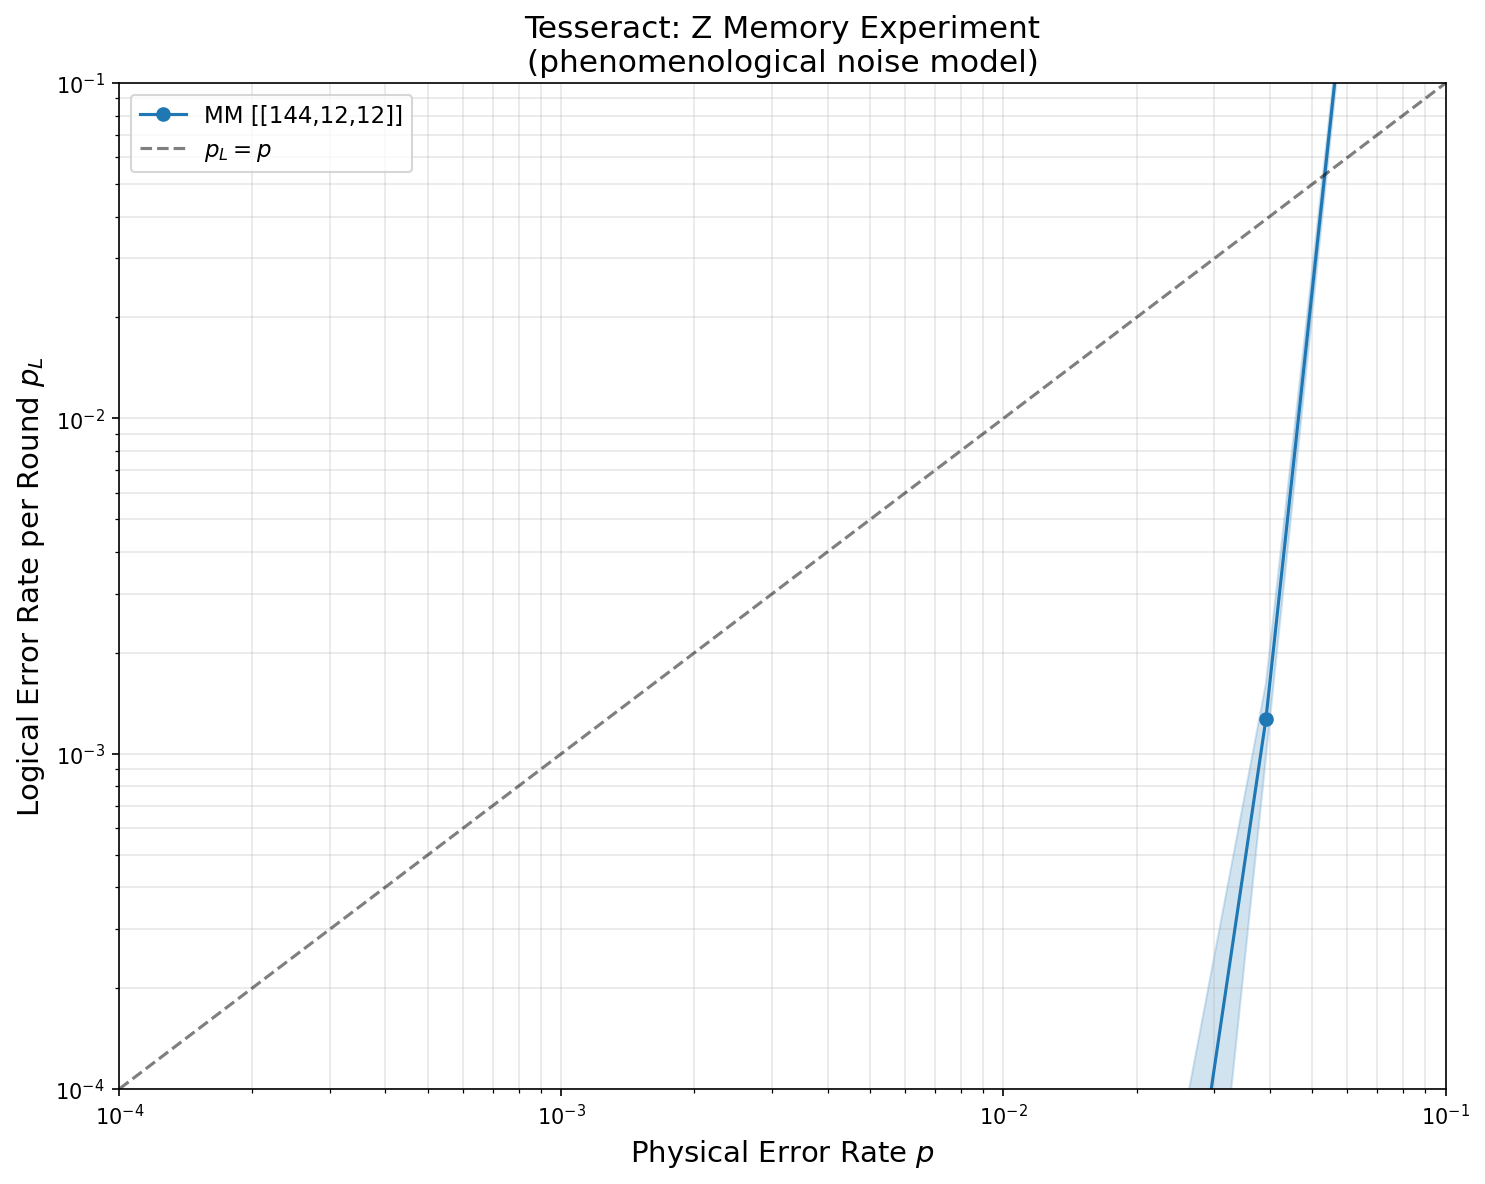

In [13]:
plot_results(all_stats, BASIS, DECODER_NAME)